2D system of ReLU units. Dynamics are:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
W = \begin{pmatrix}
w_{11} & w_{21}\\
w_{12} & w_{22}
\end{pmatrix}
\end{equation}

Each entry in W evolves as:

\begin{equation} 
    \dot{w}_{ij}(t) = - \tilde{x}_i(t) x_j(t) + x_i(t) \tilde{x}_j(t) - x_i (1 - x_i) + x_j (1 - x_j)
\end{equation}

where the $\sim$ denotes a convolutions with an exponentially decaying filter:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-(t - s)/\tau} x(s) \, ds
\end{equation}

For small $\tau$, we can define $v = t - s$. Substituting $s = t - v$ and $dv = -ds$ and changing the integration bounds, we have:

\begin{equation}
    \tilde{x}(t) = \int_t^0 e^{-v/\tau} x(t-v) \, (-dv) = \int_0^t e^{-v/\tau} x(t-v) \, dv
\end{equation}

$x(t-v)$ will only contribute if $v$ is small relative to $tau$, thus we can substitute:

\begin{equation}
    x(t-v) = x(t) - v x'(t) \; + \; ...
\end{equation}

This yields:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-v/\tau} \left(x(t) - v x'(t)\right)  \, dv
\end{equation}

Assuming $\tau << t$, we can use the  identity:

\begin{equation}
    \int_0^{\infty} v^n e^{-v/\tau} = n! \; \tau^{n+1}
\end{equation}

Thus,

\begin{equation}
    \tilde{x}(t) = \tau x(t) - \tau^2 \dot{x}(t)
\end{equation}

The equation governing $W$ then becomes:

\begin{equation}
    \dot{w}_{ij}(t) = - \left(\tau x_i(t) - \tau^2 \dot{x}_i(t)\right) x_j(t) + x_i(t) \left(\tau x_j(t) - \tau^2 \dot{x}_j(t)\right)  - x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[\dot{x}_i(t) x_j(t) - x_i(t) \dot{x}_j(t)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can now search for fixed points of the system by setting all fixed points to zero:

\begin{equation}
    0 = - x_1 (1 - x_1) + x_2 (1 - x_2)
\end{equation}

\begin{equation}
    0 = (w_{11} - 1) x_1 + w_{21} x_2 + u_1
\end{equation}

\begin{equation}
    0 = w_{12} x_1 + (w_{22} - 1) x_2 + u_2
\end{equation}


    

The first equation can be rewritten as

\begin{equation}
    0 = (x_2 - x_1) (1 - (x_1 + x_2))
\end{equation}

yielding that either $x_1 = x_2$ or $x_2 = 1 - x_1$.

Substituting the latter into the second equation yields:

\begin{equation}
    0 = (w_{11} - 1) x_1 + w_{21} (1 - x_1) + u_1
\end{equation}

Regrouping terms

\begin{equation}
    0 = (w_{11} - 1 - w_{21}) x_1 + w_{21} + u_1
\end{equation}

This equation can be satisfied for arbitrary $x_1$ if

\begin{equation}
    w_{11} - 1 - w_{21} = 0
\end{equation}

\begin{equation}
    w_{21} + u_1 = 0
\end{equation}

Similarly, subsituting $x_2 = 1 - x_1$ into the last equation yields:

\begin{equation}
    0 = w_{12} x_1 + (w_{22} - 1) (1 - x_1) + u_2
\end{equation}

\begin{equation}
    0 = (w_{12} - w_{22} + 1) x_1 + w_{22} - 1 + u_2
\end{equation}

This can be true for arbitray $x_1$ if:

\begin{equation}
    0 = w_{12} - w_{22} + 1
\end{equation}

\begin{equation}
    0 = w_{22} - 1 + u_2
\end{equation}

In summary, we have found a line of fixed points corresponding to

\begin{equation}
    x_{2} = 1 - x_1
\end{equation}

\begin{equation}
    w_{12} = -u_2
\end{equation}

\begin{equation}
    w_{21} = -u_1
\end{equation}

for arbitrary $x_1$ under the conditions that:

\begin{equation}
    w_{22} = 1 - u_2
\end{equation}

\begin{equation}
    w_{11} = 1 - u_1
\end{equation}

Note, $w_{11}$ and $w_{22}$ do not evolve under the synaptic update rule since setting $i = j$ leads the update to be zero.




To determine the stability of the fixed point, we must linearize the dynamics about a point of this fixed line.

The total dynamics of the system are given by:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[\dot{x}_i(t) x_j(t) - x_i(t) \dot{x}_j(t)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can substitute the first equation into the second to get:

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[((w_{ii}-1) x_i + w_{ji} x_j + u_i) x_j(t) - x_i(t) ((w_{jj}-1) x_j + w_{ij} x_i + u_j)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can now compute the Jacobian of this system about the fixed line described. We define:

\begin{equation}
    \theta = \begin{pmatrix}
    x_1 \\
    x_2 \\
    w_{21} \\
    w_{12} \\
    \end{pmatrix}
\end{equation}

We would like to compute:

\begin{equation}
    \frac{d}{d \theta} \dot{\theta} |_{\theta^*(x_1^*)} = \frac{d}{d \theta}  F(\theta) |_{\theta^*(x_1^*)}
\end{equation}

where

\begin{equation}
    \theta^*(x_1^*) = \begin{pmatrix}
    x_1^* \\
    1 - x_1^* \\
    -u_1 \\
    -u_2 \\
    \end{pmatrix}
\end{equation}

The full Jacobian is given by:

\begin{equation}
J =
\begin{bmatrix}
\frac{\partial \dot{x_i}}{\partial x_i} & \frac{\partial \dot{x_i}}{\partial x_j} & \frac{\partial \dot{x_i}}{\partial w_{ji}} & \frac{\partial \dot{x_i}}{\partial w_{ij}} \\
\frac{\partial \dot{x_j}}{\partial x_i} & \frac{\partial \dot{x_j}}{\partial x_j} & \frac{\partial \dot{x_j}}{\partial w_{ji}} & \frac{\partial \dot{x_j}}{\partial w_{ij}} \\
\frac{\partial \dot{w}_{ji}}{\partial x_i} & \frac{\partial \dot{w}_{ji}}{\partial x_j} & \frac{\partial \dot{w}_{ji}}{\partial w_{ji}} & \frac{\partial \dot{w}_{ji}}{\partial w_{ij}} \\
\frac{\partial \dot{w}_{ij}}{\partial x_i} & \frac{\partial \dot{w}_{ij}}{\partial x_j} & \frac{\partial \dot{w}_{ij}}{\partial w_{ji}} & \frac{\partial \dot{w}_{ij}}{\partial w_{ij}}
\end{bmatrix}
\end{equation}

About the fixed point, this is

\begin{equation}
J\Big|_{\theta^*} =
\begin{bmatrix}
-u_i & -u_i & 1 - x_i^* & 0 \\[6pt]
-u_j & -u_j & 0 & x_i^* \\[6pt]
\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) + 1 - 2x_i^* &
\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) + 1 - 2x_i^* &
-\tau^{2}\,(1 - x_i^*)^{2} & \tau^{2}\,(x_i^*)^{2} \\[6pt]
-\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) - 1 + 2x_i^* &
-\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) - 1 + 2x_i^* &
\tau^{2}\,(1 - x_i^*)^{2} & -\,\tau^{2}\,(x_i^*)^{2}
\end{bmatrix}
\end{equation}

In [10]:
%load_ext autoreload
%autoreload 2

import sympy as sp

# Define symbols
x1, u1, u2, tau = sp.symbols('x1 u1 u2 tau', real=True)

# Define the Jacobian matrix
J = sp.Matrix([
    [-u1, -u1, 1 - x1, 0],
    [-u2, -u2, 0, x1],
    [tau**2 * (u1 - x1 * (u1 + u2)) + 1 - 2*x1,
     tau**2 * (u1 - x1 * (u1 + u2)) + 1 - 2*x1,
     -tau**2 * (1 - x1)**2,
     tau**2 * x1**2],
    [-tau**2 * (u1 - x1 * (u1 + u2)) - 1 + 2*x1,
     -tau**2 * (u1 - x1 * (u1 + u2)) - 1 + 2*x1,
     tau**2 * (1 - x1)**2,
     -tau**2 * x1**2]
])

# Compute eigenvalues
eigenvals = J.eigenvals()

# Compute eigenvectors
eigenvects = J.eigenvects()

print(len(eigenvects))

for eig in eigenvects:
    val, mult, vects = eig
    print(f"\nEigenvalue: {sp.simplify(val)}")
    print("Eigenvectors:")
    for v in vects:
        print(f"  {sp.simplify(v)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
3

Eigenvalue: 0
Eigenvectors:
  Matrix([[-1], [1], [0], [0]])

Eigenvalue: -tau**2*x1**2 + tau**2*x1 - tau**2/2 - u1/2 - u2/2 - sqrt(4*tau**4*x1**4 - 8*tau**4*x1**3 + 8*tau**4*x1**2 - 4*tau**4*x1 + tau**4 + 4*tau**2*u1*x1**2 - 8*tau**2*u1*x1 + 2*tau**2*u1 + 4*tau**2*u2*x1**2 - 2*tau**2*u2 + u1**2 + 2*u1*u2 + u2**2 + 16*x1**2 - 16*x1 + 4)/2
Eigenvectors:
  Matrix([[(2*tau**4*u1*x1**4 - 2*tau**4*u1*x1**3 + tau**4*u1*x1**2 - 2*tau**4*u2*x1**4 + 4*tau**4*u2*x1**3 - 3*tau**4*u2*x1**2 + tau**4*u2*x1 + tau**2*u1**2*x1**2 - tau**2*u1**2*x1 + 2*tau**2*u1*u2*x1 - tau**2*u1*u2 - tau**2*u2**2*x1**2 + tau**2*u2**2*x1 - 4*tau**2*x1**4 + 10*tau**2*x1**3 - 10*tau**2*x1**2 + 5*tau**2*x1 - tau**2 + 2*u1*x1**2 - u1*x1 - 2*u2*x1**2 + 3*u2*x1 - u2 - (2*tau**2*x1**2 - 2*tau**2*x1 + tau**2 + u1 + u2 + sqrt(4*tau**4*x1**4 - 8*tau**4*x1**3 + 8*tau**4*x1**2 - 4*tau**4*x1 + tau**4 + 4*tau**2*u1*x1**2 - 8*tau**2*u1*x1 + 2*tau

$$
\lambda_{\pm} = -\tau^2 x_1^2 + \tau^2 x_1 - \frac{\tau^2}{2} - \frac{u_1}{2} - \frac{u_2}{2} \;\pm\; \frac{1}{2} \sqrt{ 4 \tau^4 x_1^4 - 8 \tau^4 x_1^3 + 8 \tau^4 x_1^2 - 4 \tau^4 x_1 + \tau^4 + 4 \tau^2 u_1 x_1^2 - 8 \tau^2 u_1 x_1 + 2 \tau^2 u_1 + 4 \tau^2 u_2 x_1^2 - 2 \tau^2 u_2 + u_1^2 + 2 u_1 u_2 + u_2^2 + 16 x_1^2 - 16 x_1 + 4 }
$$

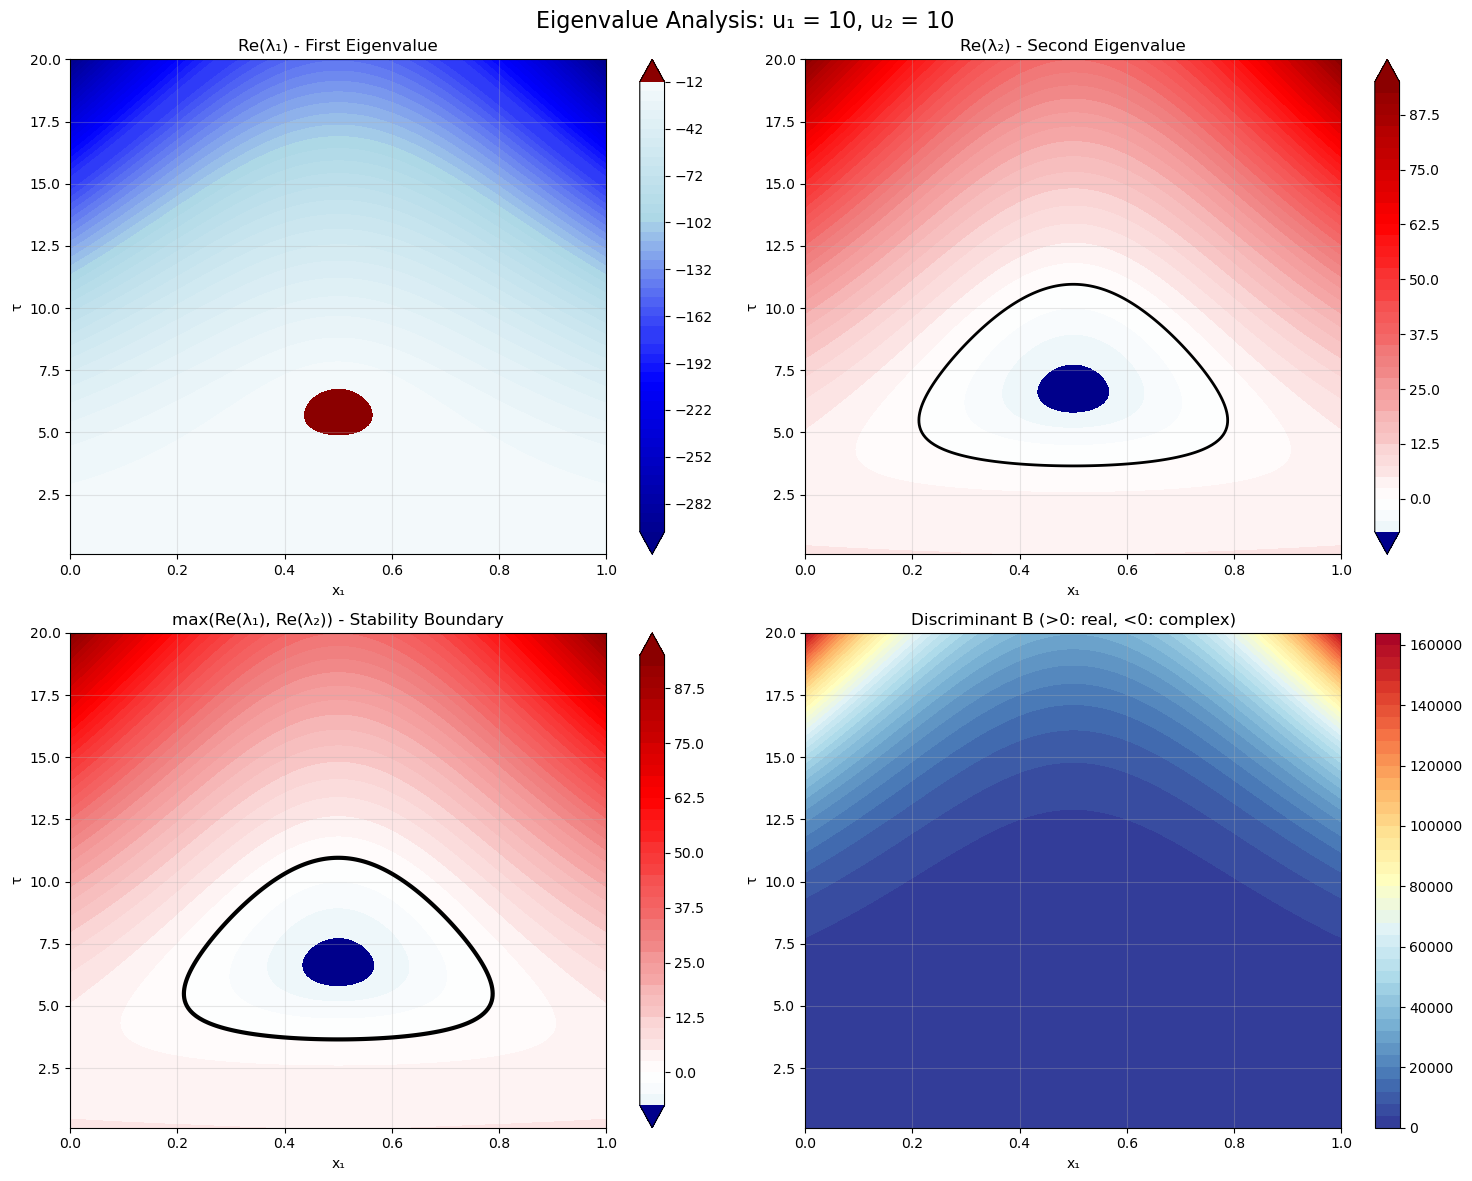

Analysis for u₁ = 10, u₂ = 10:
x₁ range: [0, 1]
τ range: [0.1, 20]

Stability regions (where max real part < 0):
Stable region covers 15.3% of parameter space

Key observations:
- Black contour lines show zero real part (stability boundary)
- Blue regions: stable (negative real parts)
- Red regions: unstable (positive real parts)
- Bottom right plot shows real vs complex eigenvalue regions


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Parameters
u1 = 10
u2 = 10

# Grid ranges
x1_min, x1_max = 0, 1
tau_min, tau_max = 0.1, 20
resolution = 200

# Create meshgrid
x1_vals = np.linspace(x1_min, x1_max, resolution)
tau_vals = np.linspace(tau_min, tau_max, resolution)
X1, TAU = np.meshgrid(x1_vals, tau_vals)

# Calculate eigenvalue components
def calculate_eigenvalues(x1, tau, u1, u2):
    # A term (common part)
    A = -tau**2 * x1**2 + tau**2 * x1 - tau**2/2 - u1/2 - u2/2
    
    # Discriminant B
    B = (4*tau**4*x1**4 - 8*tau**4*x1**3 + 8*tau**4*x1**2 - 4*tau**4*x1 + tau**4 + 
         4*tau**2*u1*x1**2 - 8*tau**2*u1*x1 + 2*tau**2*u1 + 
         4*tau**2*u2*x1**2 - 2*tau**2*u2 + 
         u1**2 + 2*u1*u2 + u2**2 + 16*x1**2 - 16*x1 + 4)
    
    # Handle complex square root
    sqrt_B = np.sqrt(np.abs(B)) * np.sign(B) * (B >= 0) + 1j * np.sqrt(np.abs(B)) * (B < 0)
    
    # Two eigenvalues
    lambda1 = (A - sqrt_B) / 2
    lambda2 = (A + sqrt_B) / 2
    
    return lambda1, lambda2, B

# Calculate eigenvalues over the grid
lambda1, lambda2, discriminant = calculate_eigenvalues(X1, TAU, u1, u2)

# Extract real parts
lambda1_real = np.real(lambda1)
lambda2_real = np.real(lambda2)

# Create the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Eigenvalue Analysis: u₁ = {u1}, u₂ = {u2}', fontsize=16)

# Custom colormap: blue (negative) to white (zero) to red (positive)
colors = ['darkblue', 'blue', 'lightblue', 'white', 'lightcoral', 'red', 'darkred']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('stability', colors, N=n_bins)

# Function to create symmetric color limits around zero
def get_symmetric_limits(data):
    abs_max = np.max(np.abs(data))
    return -abs_max, abs_max

# Plot 1: Lambda 1 real part
vmin1, vmax1 = get_symmetric_limits(lambda1_real)
im1 = axes[0,0].contourf(X1, TAU, lambda1_real, levels=50, cmap=cmap, vmin=vmin1, vmax=vmax1, extend='both')
axes[0,0].contour(X1, TAU, lambda1_real, levels=[0], colors='black', linewidths=2)
axes[0,0].set_xlabel('x₁')
axes[0,0].set_ylabel('τ')
axes[0,0].set_title('Re(λ₁) - First Eigenvalue')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes[0,0])

# Plot 2: Lambda 2 real part
vmin2, vmax2 = get_symmetric_limits(lambda2_real)
im2 = axes[0,1].contourf(X1, TAU, lambda2_real, levels=50, cmap=cmap, vmin=vmin2, vmax=vmax2, extend='both')
axes[0,1].contour(X1, TAU, lambda2_real, levels=[0], colors='black', linewidths=2)
axes[0,1].set_xlabel('x₁')
axes[0,1].set_ylabel('τ')
axes[0,1].set_title('Re(λ₂) - Second Eigenvalue')
axes[0,1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes[0,1])

# Plot 3: Maximum real part (determines stability)
max_real = np.maximum(lambda1_real, lambda2_real)
vmin3, vmax3 = get_symmetric_limits(max_real)
im3 = axes[1,0].contourf(X1, TAU, max_real, levels=50, cmap=cmap, vmin=vmin3, vmax=vmax3, extend='both')
axes[1,0].contour(X1, TAU, max_real, levels=[0], colors='black', linewidths=3)
axes[1,0].set_xlabel('x₁')
axes[1,0].set_ylabel('τ')
axes[1,0].set_title('max(Re(λ₁), Re(λ₂)) - Stability Boundary')
axes[1,0].grid(True, alpha=0.3)
plt.colorbar(im3, ax=axes[1,0])

# Plot 4: Discriminant (shows real vs complex eigenvalues)
im4 = axes[1,1].contourf(X1, TAU, discriminant, levels=50, cmap='RdYlBu_r')
axes[1,1].contour(X1, TAU, discriminant, levels=[0], colors='black', linewidths=2)
axes[1,1].set_xlabel('x₁')
axes[1,1].set_ylabel('τ')
axes[1,1].set_title('Discriminant B (>0: real, <0: complex)')
axes[1,1].grid(True, alpha=0.3)
plt.colorbar(im4, ax=axes[1,1])

plt.tight_layout()
plt.show()

# Print some analysis
print(f"Analysis for u₁ = {u1}, u₂ = {u2}:")
print(f"x₁ range: [{x1_min}, {x1_max}]")
print(f"τ range: [{tau_min}, {tau_max}]")
print(f"")
print("Stability regions (where max real part < 0):")
stable_mask = max_real < 0
stable_fraction = np.sum(stable_mask) / (resolution * resolution)
print(f"Stable region covers {stable_fraction:.1%} of parameter space")

# Find approximate stability boundaries
print(f"")
print("Key observations:")
print("- Black contour lines show zero real part (stability boundary)")
print("- Blue regions: stable (negative real parts)")
print("- Red regions: unstable (positive real parts)")
print("- Bottom right plot shows real vs complex eigenvalue regions")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

class LinearSystem:
    def __init__(self, u, tau=1.0, x1_init=0.5, noise_std=0, off_diagonal_weight_perturbation=0, learning_rate=1, homeo_rate=0.05):
        """
        Initialize the 2D linear system
        
        Parameters:
        u: array-like, input vector [u1, u2]
        tau: float, time constant parameter
        """
        self.u = np.array(u)
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        
        # Initial conditions based on your specification
        # w_ii = 1 - u_i; w_ij = u_j
        w_12 = -u[1] * np.random.normal(loc=1, scale=off_diagonal_weight_perturbation)
        w_21 = -u[0] * np.random.normal(loc=1, scale=off_diagonal_weight_perturbation)

        w_11 = 0.7
        w_22 = 0.4
        
        self.W0 = np.array([[w_11, w_21],
                           [w_12, w_22]])
        
        # x_j = 1 - x_i (assuming some initial values)
        # Let's set x1 initial, then x2 = 1 - x1
        self.x0 = np.clip(np.array([x1_init, 1 - x1_init]) + np.random.normal(loc=np.zeros(2), scale=np.ones(2) * noise_std), 0, 1)
        
        # print(f"Initial conditions:")
        # print(f"W0 = \n{self.W0}")
        # print(f"x0 = {self.x0}")
        # print(f"u = {self.u}")
        # print(f"tau = {self.tau}")
    
    def system_dynamics(self, state, t):
        """
        Define the system of differential equations
        
        state = [x1, x2, w11, w12, w21, w22]
        """
        x1, x2, w11, w12, w21, w22 = state
        
        # Current state vector and weight matrix
        x = np.clip(np.array([x1, x2]), 0, None)
        W = np.array([[w11, w21], [w12, w22]])
        
        # State dynamics: dx/dt = Wx - x + u (fully linear)
        dx_dt = W @ x - x + self.u
        dx_dt = np.where(np.logical_and(x <= 0, dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt
        
        
        # Weight dynamics: dw_ij/dt = tau^2 * [dx_i/dt * x_j - x_i * dx_j/dt] - x_i(1-x_i) + x_j(1-x_j)
        homeo_rate = self.homeo_rate
        if self.learning_rate == 0:
            dw11_dt, dw12_dt, dw21_dt, dw22_dt = 0, 0, 0, 0
        else:
            # dw11_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[0] - x[0] * dx1_dt) + homeo_rate * (- x[0] * (1 - x[0]) + x[0] * (1 - x[0])))
            # dw12_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[1] - x[0] * dx2_dt) + homeo_rate * (- x[0] * (1 - x[0]) + x[1] * (1 - x[1])))
            # dw21_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[0] - x[1] * dx1_dt) + homeo_rate * (- x[1] * (1 - x[1]) + x[0] * (1 - x[0])))
            # dw22_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[1] - x[1] * dx2_dt) + homeo_rate * (- x[1] * (1 - x[1]) + x[1] * (1 - x[1])))

            # dw11_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[0] - x[0] * dx1_dt) + homeo_rate * (0.5 - x[0]))
            # dw12_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[1] - x[0] * dx2_dt) + homeo_rate * (0.5 - 0.5 * x[0]- 0.5 * x[1]))
            # dw21_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[0] - x[1] * dx1_dt) + homeo_rate * (0.5 - 0.5 * x[0] - 0.5 * x[1]))
            # dw22_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[1] - x[1] * dx2_dt) + homeo_rate * (0.5 - x[1]))

            # dw11_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[0] - x[0] * dx1_dt) + homeo_rate * (0.5 - w11))
            # dw12_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[1] - x[0] * dx2_dt))
            # dw21_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[0] - x[1] * dx1_dt))
            # dw22_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[1] - x[1] * dx2_dt) + homeo_rate * (0.5 - w22))

            dw11_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[0] - x[0] * dx1_dt) + homeo_rate * x[0] * (0.5 - x[0]))
            dw12_dt = self.learning_rate * (self.tau**2 * (dx1_dt * x[1] - x[0] * dx2_dt) + homeo_rate * x[0] * (0.5 - x[0]))
            dw21_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[0] - x[1] * dx1_dt) + homeo_rate * x[1] * (0.5 - x[1]))
            dw22_dt = self.learning_rate * (self.tau**2 * (dx2_dt * x[1] - x[1] * dx2_dt) + homeo_rate * x[1] * (0.5 - x[1]))
        
        return [dx1_dt, dx2_dt, dw11_dt, dw12_dt, dw21_dt, dw22_dt]
    
    def simulate(self, t_span, dt=0.002):
        """
        Simulate the system over time
        
        Parameters:
        t_span: tuple, (start_time, end_time)
        dt: float, time step
        """
        t = np.arange(t_span[0], t_span[1], dt)
        
        # Initial state vector
        initial_state = [self.x0[0], self.x0[1], 
                        self.W0[0,0], self.W0[0,1], self.W0[1,0], self.W0[1,1]]
        
        # Solve the ODE system
        solution = odeint(self.system_dynamics, initial_state, t)
        
        # Extract results
        x1, x2 = solution[:, 0], solution[:, 1]
        w11, w12, w21, w22 = solution[:, 2], solution[:, 3], solution[:, 4], solution[:, 5]
        
        return t, x1, x2, w11, w12, w21, w22

# Example usage and parameter exploration
def run_simulation(learning_rate=1, homeo_rate=0.05, seed=None, t_sim=(0, 200)):
    # Example parameters
    u = [0.5, 0.5]  # Input vector
    tau = 2.0       # Time constant
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)
    x1_init_values = np.clip(np.linspace(0.05, 0.95, 30), 0, 1)  # 30 different initial conditions
    colors = plt.cm.viridis(np.linspace(0, 1, len(x1_init_values)))
    
    # Storage for all simulations
    all_results = []
    
    # Set up the plot (now 2x2 instead of 2x3)
    scale = 0.75
    fig, axes = plt.subplots(2, 2, figsize=(12 * scale, 10 * scale))
    fig.suptitle(f'Multiple Initial Conditions (u={u}, τ={tau})', 
                 fontsize=16, fontweight='bold')
    
    print(f"Running simulations for {len(x1_init_values)} initial conditions...")

    axes[0, 1].plot([1, 0], [0, 1], '--', c='gray')
    
    for i, (x1_init, color) in enumerate(zip(x1_init_values, colors)):
        # Create system with this initial condition
        system = LinearSystem(u, tau, x1_init=x1_init, noise_std=0.1, 
                            off_diagonal_weight_perturbation=0.4, learning_rate=learning_rate, homeo_rate=homeo_rate)
        
        # Simulate
        t, x1, x2, w11, w12, w21, w22 = system.simulate(t_sim, dt=0.002)
        all_results.append((t, x1, x2, w11, w12, w21, w22))
        
        # Plot state variables
        axes[0, 0].plot(t, x1, color=color, linewidth=1.5, alpha=0.8)
        axes[0, 0].plot(t, x2, color=color, linewidth=1.5, alpha=0.6, linestyle='--')
        
        # Phase portrait
        axes[0, 1].plot(x1, x2, color=color, linewidth=2, alpha=0.8)
        axes[0, 1].scatter(x1[0], x2[0], marker='o',  edgecolor=color, facecolor='none', s=50, alpha=0.8)
        axes[0, 1].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
        
        # Weight matrix diagonal elements
        axes[1, 0].plot(t, w11, color=color, linewidth=1.5, alpha=0.8)
        axes[1, 0].plot(t, w22, color=color, linewidth=1.5, alpha=0.6, linestyle='--')
        
        # Off-diagonal weights
        axes[1, 1].plot(t, w12, color=color, linewidth=1.5, alpha=0.8)
        axes[1, 1].plot(t, w21, color=color, linewidth=1.5, alpha=0.6, linestyle='--')
    
    # Configure all subplots
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('State Variables')
    axes[0, 0].set_title('State Evolution (solid=x₁, dashed=x₂)')
    axes[0, 0].grid(True, alpha=0.3)
    # axes[0, 0].set_ylim(-0.1, 1.1)
    
    axes[0, 1].set_xlabel('x₁')
    axes[0, 1].set_ylabel('x₂')
    axes[0, 1].set_title('Phase Portraits (○=start, ●=end)')
    axes[0, 1].grid(True, alpha=0.3)
    # axes[0, 1].set_xlim(-0.1, 1.1)
    # axes[0, 1].set_ylim(-0.1, 1.1)
    
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Diagonal Weights')
    axes[1, 0].set_title('Diagonal Weights (solid=w₁₁, dashed=w₂₂)')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Off-diagonal Weights')
    axes[1, 1].set_title('Off-diagonal Weights (solid=w₁₂, dashed=w₂₁)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return all_results

Running simulations for 30 initial conditions...


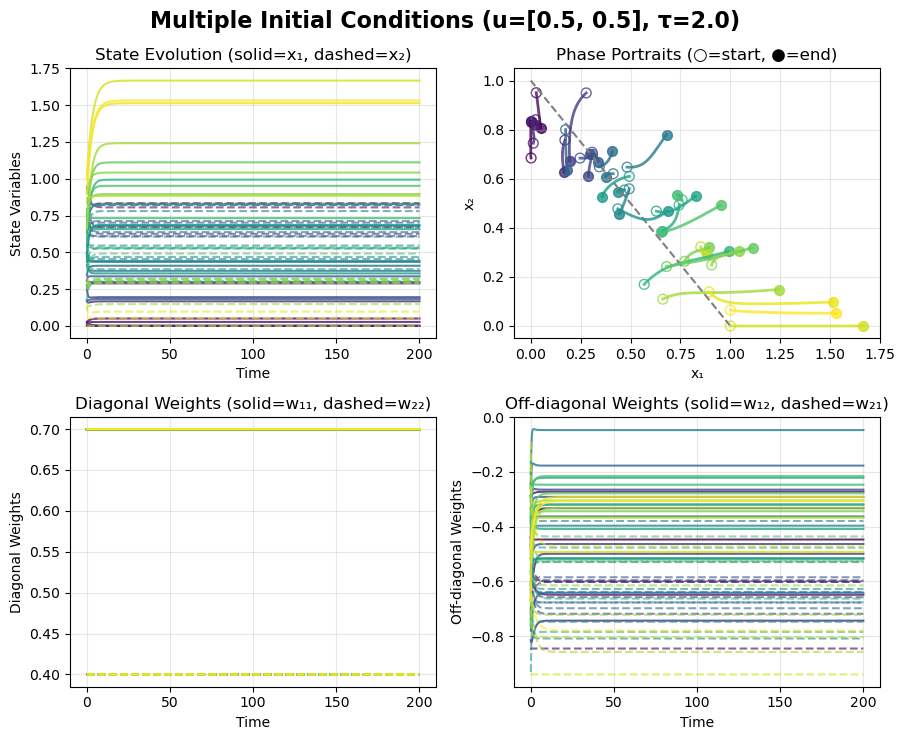

In [2]:
run_simulation(homeo_rate=0, seed=11)
None

Running simulations for 30 initial conditions...


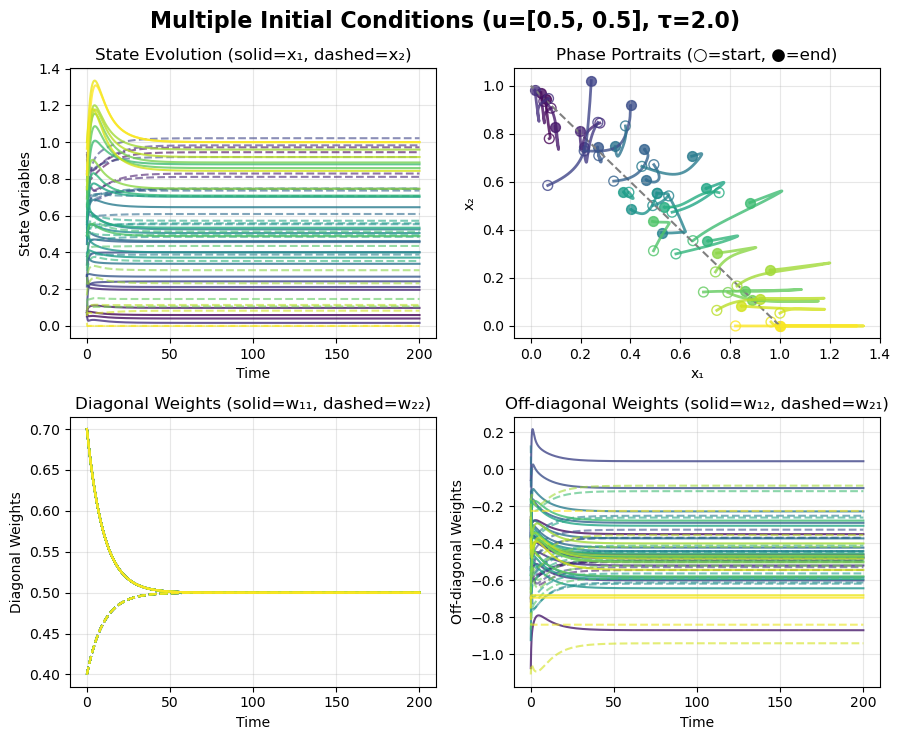

In [92]:
run_simulation(homeo_rate=0.1, seed=12)
None

Running simulations for 30 initial conditions...


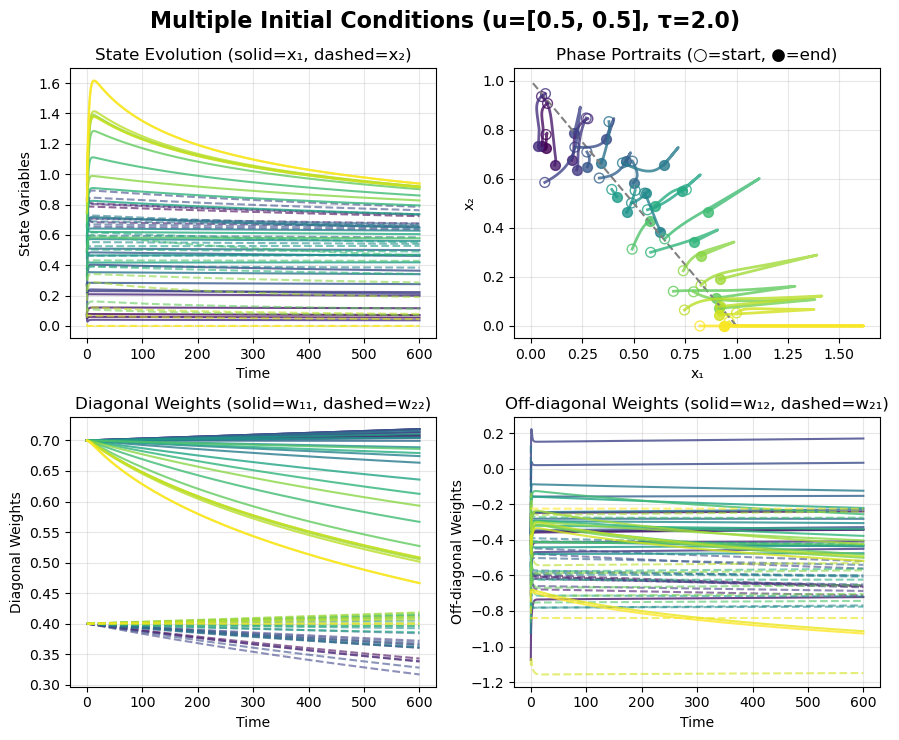

In [3]:
run_simulation(homeo_rate=0.0005, seed=12, t_sim=(0, 600))
None

Running simulations for 30 initial conditions...


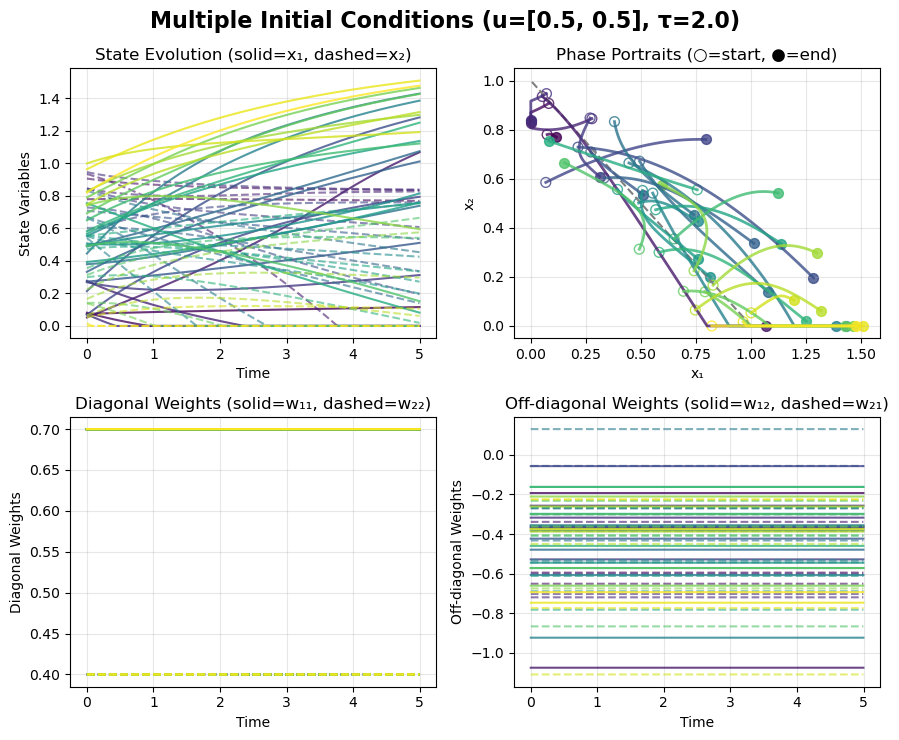

In [96]:
run_simulation(learning_rate=0, t_sim=(0, 5), seed=12)
None

Running simulations for 30 initial conditions...


/tmp/ipykernel_1033294/59156352.py:95: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = odeint(self.system_dynamics, initial_state, t)


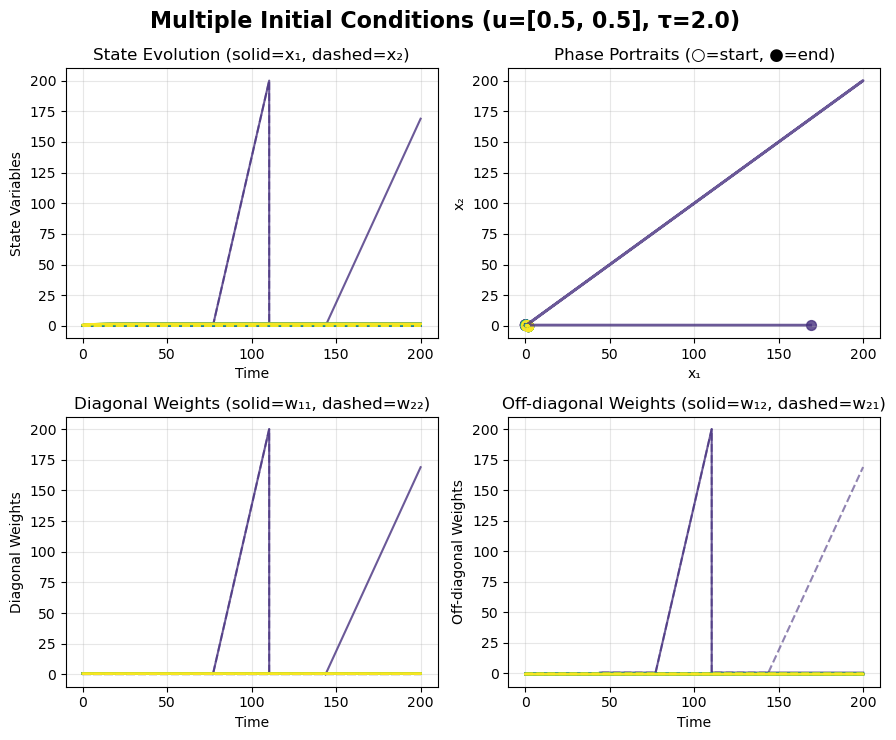

In [86]:
run_simulation(learning_rate=0)
None

Running simulations for 30 initial conditions...


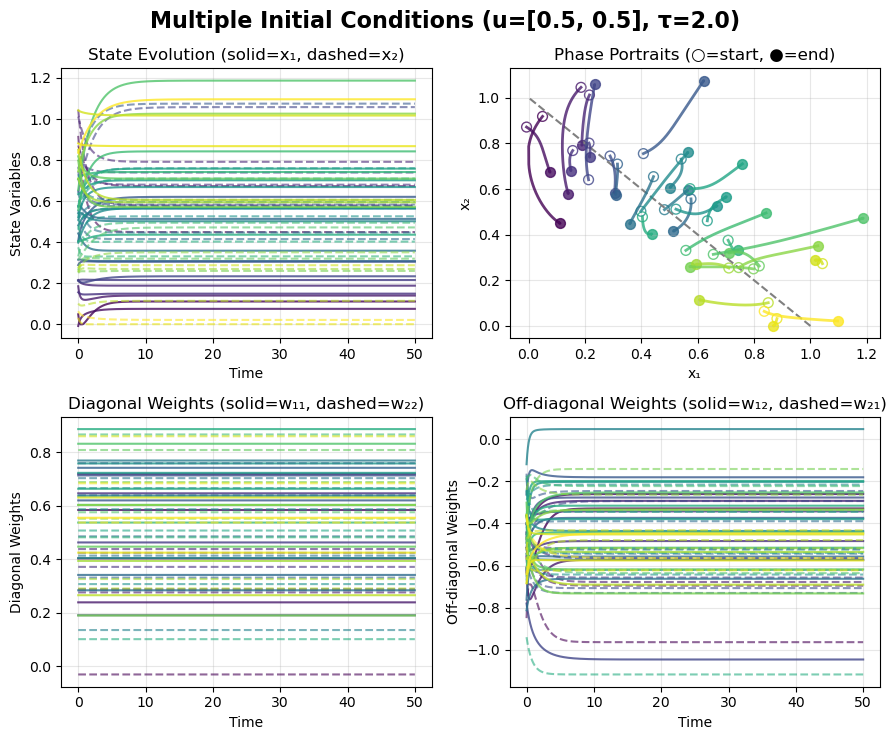

In [148]:
run_simulation(learning_rate=1, homeo_rate=0, seed=11)
None